In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iiot-deeplearning\models"

X_train = np.load(os.path.join(PROCESSED, "X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "y_test.npy"))
class_weights_arr = np.load(os.path.join(PROCESSED, "class_weights.npy"), allow_pickle=True)
class_weights = {0: float(class_weights_arr[0]), 1: float(class_weights_arr[1])}

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"TensorFlow: {tf.__version__}")

# ── Build MLP ─────────────────────────────────────────────────────────────
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(50,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch: {early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 100}")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate_dl(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred, y_prob

y_pred_val, _ = evaluate_dl(model, X_val, y_val, "Validation")
y_pred_test, _ = evaluate_dl(model, X_test, y_test, "Test")

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'])
plt.title('MLP — DataSense IIoT 2025')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "cm_mlp.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

# ── Training Curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('black')
for ax in [ax1, ax2]:
    ax.set_facecolor('black')

ax1.plot(history.history['loss'], color='#00cc88', label='Train Loss')
ax1.plot(history.history['val_loss'], color='#7030A0', label='Val Loss')
ax1.set_title('MLP — Loss Curves', color='white')
ax1.set_xlabel('Epoch', color='white'); ax1.set_ylabel('Loss', color='white')
ax1.tick_params(colors='white'); ax1.legend(facecolor='black', labelcolor='white')
ax1.grid(color='#333333')

ax2.plot(history.history['accuracy'], color='#00cc88', label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], color='#7030A0', label='Val Accuracy')
ax2.set_title('MLP — Accuracy Curves', color='white')
ax2.set_xlabel('Epoch', color='white'); ax2.set_ylabel('Accuracy', color='white')
ax2.tick_params(colors='white'); ax2.legend(facecolor='black', labelcolor='white')
ax2.grid(color='#333333')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "mlp_training_curves.png"), dpi=150, facecolor='black')
plt.show()

model.save(os.path.join(MODELS, "mlp.keras"))
print("Model saved.")

Train: (31538, 50), Val: (6758, 50), Test: (6759, 50)
TensorFlow: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,273 (212.00 KB)

 Trainable params: 54,273 (212.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8213 - loss: 0.4322 - val_accuracy: 0.9137 - val_loss: 0.2484
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9084 - loss: 0.2810 - val_accuracy: 0.9219 - val_loss: 0.2276
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9144 - loss: 0.2582 - val_accuracy: 0.9239 - val_loss: 0.2190
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9178 - loss: 0.2474 - val_accuracy: 0.9299 - val_loss: 0.2101
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9206 - loss: 0.2381 - val_accuracy: 0.9319 - val_loss: 0.2045
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9242 - loss: 0.2319 - val_accuracy: 0.9343 - val_loss: 0.1988
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9282 - loss: 0.2266 - val_accuracy: 0.9362 - val_loss: 0.1970
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9293 - loss: 0.2193 - val_accuracy: 0.9380 - 

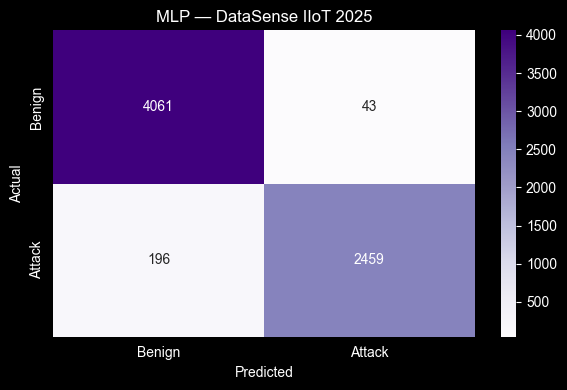


TN: 4061  FP: 43  FN: 196  TP: 2459


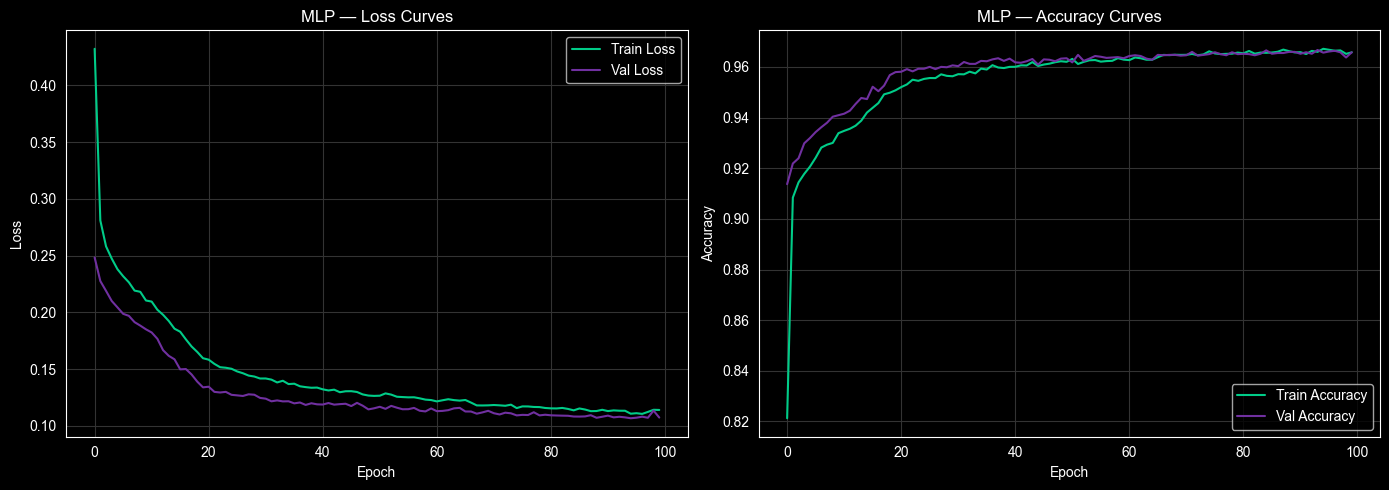

Model saved.


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 5 SUMMARY — MLP on DataSense CIC IIoT 2025
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: Multilayer Perceptron (Deep Learning)
# Config: 256→128→64, ReLU, Dropout 0.3, early stopping patience=10
# Converged at: epoch 100 (ran full — still slowly improving)
#
# RESULTS:
#   F1:        0.9537
#   AUC-ROC:   0.9861
#   Precision: 0.9828
#   Recall:    0.9262
#   Accuracy:  0.9646
#
# KEY OBSERVATION:
#   MLP ran the full 100 epochs without early stopping — val loss still
#   slowly decreasing. Results competitive but below both XGBoost and
#   Random Forest. High precision (0.9828) but recall trails classical ML.
#
# LEADERBOARD:
#   1. XGBoost            F1=0.9678  AUC=0.9917
#   2. Random Forest      F1=0.9643  AUC=0.9916
#   3. MLP                F1=0.9537  AUC=0.9861
#   4. Logistic Regression F1=0.8933  AUC=0.9505
# ══════════════════════════════════════════════════════════════════════════